 任务1：可配置 Producer-Consumer 实验平台

本实验实现：
1. 多线程 Producer / Consumer，队列中间件使用 `queue.Queue`
2. Producer 基于 `m2_producer.EcommerceDataProducer.generate_event()` 产生日志事件
3. 独立监控线程每 0.5 秒采样，并写入 `experiment_metrics.csv`
4. 运行固定时长后输出统计摘要（生产总量、消费总量、丢弃总量、最终队列深度）

In [3]:
import csv
import os
import queue
import threading
import time
from datetime import datetime

from m2_producer import EcommerceDataProducer


class Producer(threading.Thread):
    def __init__(
        self,
        q,
        rate,
        stop_event,
        backpressure_on=False,
        backpressure_state=None,
        producer_config=None,
        max_backoff=5.0,
    ):
        super().__init__(daemon=True)
        self.q = q
        self.rate = rate
        self.stop_event = stop_event
        self.backpressure_on = backpressure_on
        self.backpressure_state = backpressure_state
        self.max_backoff = max_backoff
        self.produced = 0
        self.dropped = 0
        self.data_producer = EcommerceDataProducer(**(producer_config or {}))

    def run(self):
        base_delay = 1.0 / self.rate if self.rate > 0 else 0
        current_delay = base_delay

        while not self.stop_event.is_set():
            event = self.data_producer.generate_event()
            try:
                # 当启用显式背压时，优先使用阻塞 put，让 queue.Queue(maxsize=N) 在满时自动阻塞
                if self.backpressure_on:
                    self.q.put(event)
                else:
                    try:
                        self.q.put_nowait(event)
                    except queue.Full:
                        self.dropped += 1
                        # 如果放不进去就略过
                        continue
                self.produced += 1
            except queue.Full:
                # 对于某些极端情形，捕获 Full
                self.dropped += 1

            # 根据背压状态调整发送间隔（指数退避 / 逐步恢复）
            if self.backpressure_state is not None:
                with self.backpressure_state["lock"]:
                    active = bool(self.backpressure_state.get("active", False))
                if active:
                    current_delay = min(max(base_delay, current_delay * 2), self.max_backoff)
                else:
                    # 逐步恢复，至少回到 base_delay
                    current_delay = max(base_delay, current_delay / 2) if base_delay > 0 else 0
                if current_delay > 0:
                    time.sleep(current_delay)
            else:
                if base_delay > 0:
                    time.sleep(base_delay)


class Consumer(threading.Thread):
    def __init__(self, q, process_time, stop_event, consumed_counter):
        super().__init__(daemon=True)
        self.q = q
        self.process_time = process_time
        self.stop_event = stop_event
        self.consumed_counter = consumed_counter

    def run(self):
        # 在 stop_event 被设置后，不再尝试清空队列，线程应尽快退出以避免长时间阻塞
        while not self.stop_event.is_set():
            try:
                _ = self.q.get(timeout=0.5)
                # 处理当前获取到的消息（若在此之前 stop_event 被设置，已获取的消息仍会被处理一次）
                time.sleep(self.process_time)
                with self.consumed_counter["lock"]:
                    self.consumed_counter["count"] += 1
                try:
                    self.q.task_done()
                except Exception:
                    pass
            except queue.Empty:
                continue


class MetricsCollector(threading.Thread):
    def __init__(
        self,
        q,
        max_capacity,
        producer_rate,
        consumer_time,
        n_consumers,
        backpressure_on,
        backpressure_state,
        stop_event,
        start_time,
        csv_path,
        high_threshold=0.85,
        low_threshold=0.30,
    ):
        super().__init__(daemon=True)
        self.q = q
        self.max_capacity = max_capacity
        self.producer_rate = producer_rate
        self.consumer_time = consumer_time
        self.n_consumers = n_consumers
        self.backpressure_on = backpressure_on
        self.backpressure_state = backpressure_state
        self.stop_event = stop_event
        self.start_time = start_time
        self.csv_path = csv_path
        self.high_threshold = high_threshold
        self.low_threshold = low_threshold

    def run(self):
        file_exists = os.path.exists(self.csv_path)
        file_empty = (not file_exists) or os.path.getsize(self.csv_path) == 0

        with open(self.csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            if file_empty:
                writer.writerow([
                    "timestamp",
                    "elapsed_sec",
                    "queue_depth",
                    "max_capacity",
                    "load_pct",
                    "producer_rate",
                    "consumer_time",
                    "n_consumers",
                    "backpressure_on",
                    "backpressure_active",
                ])

            # 监控循环：每 0.5s 采样并写入
            while not self.stop_event.is_set():
                now = time.time()
                elapsed = now - self.start_time
                queue_depth = self.q.qsize()
                load_pct = queue_depth / self.max_capacity if self.max_capacity > 0 else -1

                # 水位线探针：仅在有界队列且启用背压控制时生效
                back_active = False
                if self.backpressure_on and self.backpressure_state is not None and self.max_capacity > 0:
                    with self.backpressure_state["lock"]:
                        current_active = bool(self.backpressure_state.get("active", False))
                        # 触发
                        if load_pct >= self.high_threshold and not current_active:
                            self.backpressure_state["active"] = True
                            back_active = True
                            print("⚠⚠ 触发背压：下游过载，强制削峰中...")
                        elif load_pct <= self.low_threshold and current_active:
                            self.backpressure_state["active"] = False
                            back_active = False
                            print("ℹ️ 背压缓解：逐渐恢复吞吐")
                        else:
                            back_active = bool(self.backpressure_state.get("active", False))
                else:
                    back_active = False

                writer.writerow([
                    datetime.fromtimestamp(now).isoformat(),
                    round(elapsed, 2),
                    queue_depth,
                    self.max_capacity,
                    round(load_pct, 4) if load_pct != -1 else -1,
                    self.producer_rate,
                    self.consumer_time,
                    self.n_consumers,
                    self.backpressure_on,
                    back_active,
                ])
                f.flush()
                time.sleep(0.5)


def run_experiment(
    duration_sec=20,
    producer_rate=50,
    consumer_time=0.05,
    n_consumers=2,
    max_capacity=1000,
    backpressure_on=False,
    csv_path="experiment_metrics.csv",
    producer_config=None,
    reset_csv=True,
    backpressure_params=None,
):
    if reset_csv and os.path.exists(csv_path):
        os.remove(csv_path)

    # 有界/无界队列
    q = queue.Queue(max_capacity) if max_capacity > 0 else queue.Queue()
    stop_event = threading.Event()
    consumed_counter = {"count": 0, "lock": threading.Lock()}
    start_time = time.time()

    # 如果需要显式背压，创建共享状态
    backpressure_state = None
    if backpressure_on and max_capacity > 0:
        backpressure_state = {"active": False, "lock": threading.Lock()}

    producer = Producer(
        q,
        producer_rate,
        stop_event,
        backpressure_on=backpressure_on,
        backpressure_state=backpressure_state,
        producer_config=producer_config,
        max_backoff=(backpressure_params.get("max_backoff") if backpressure_params else 5.0),
    )
    consumers = [Consumer(q, consumer_time, stop_event, consumed_counter) for _ in range(n_consumers)]
    metrics = MetricsCollector(
        q,
        max_capacity if max_capacity > 0 else -1,
        producer_rate,
        consumer_time,
        n_consumers,
        backpressure_on,
        backpressure_state,
        stop_event,
        start_time,
        csv_path,
        high_threshold=(backpressure_params.get("high_threshold") if backpressure_params else 0.85),
        low_threshold=(backpressure_params.get("low_threshold") if backpressure_params else 0.30),
    )

    producer.start()
    for c in consumers:
        c.start()
    metrics.start()

    time.sleep(duration_sec)
    stop_event.set()

    producer.join()
    for c in consumers:
        c.join()
    metrics.join()

    produced = producer.produced
    dropped = producer.dropped
    with consumed_counter["lock"]:
        consumed = consumed_counter["count"]
    final_depth = q.qsize()

    summary = {
        "produced": produced,
        "consumed": consumed,
        "dropped": dropped,
        "final_queue_depth": final_depth,
        "csv_path": csv_path,
    }
    print("实验结束：")
    print(f"  生产总量: {produced}")
    print(f"  消费总量: {consumed}")
    print(f"  丢弃总量: {dropped}")
    print(f"  最终队列深度: {final_depth}")
    print(f"  指标文件: {csv_path}")
    return summary


# 示例运行（任务一只需运行本代码格）
summary = run_experiment(
    duration_sec=20,
    producer_rate=50,
    consumer_time=0.05,
    n_consumers=2,
    max_capacity=1000,
    backpressure_on=False,
    csv_path="experiment_metrics.csv",
    reset_csv=True,
    producer_config={
        "num_users": 1000,
        "num_items": 500,
        "weights": None,
        "use_zipf": True,
        "zipf_alpha": 1.2,
        "hot_item_ratio": 0.2,
        "hot_item_traffic_ratio": 0.8,
    },
)


实验结束：
  生产总量: 969
  消费总量: 794
  丢弃总量: 0
  最终队列深度: 175
  指标文件: experiment_metrics.csv


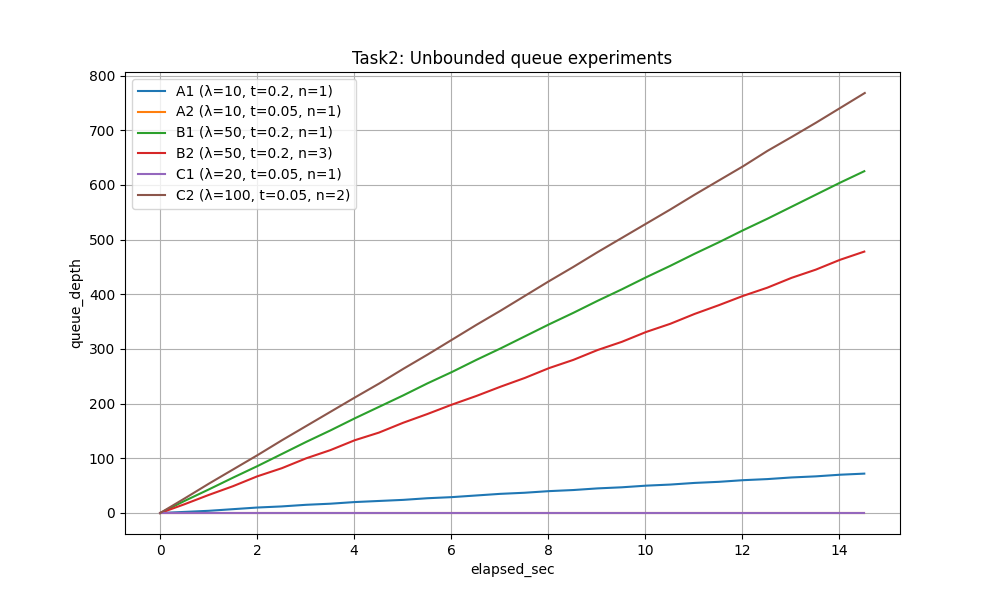

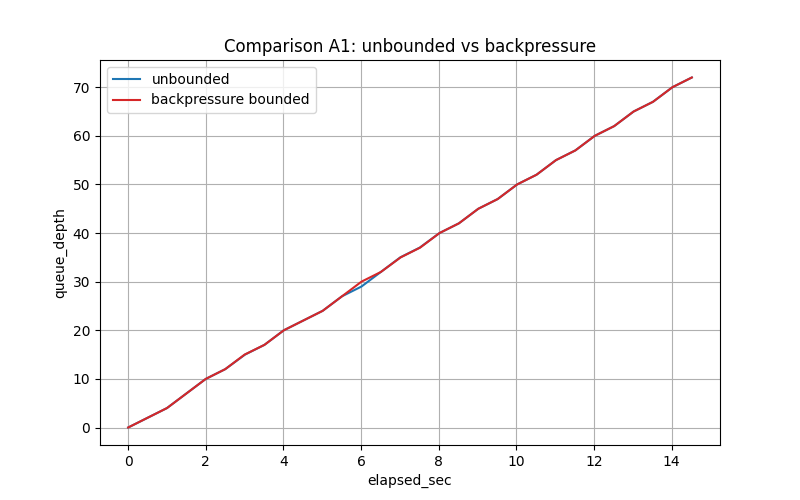

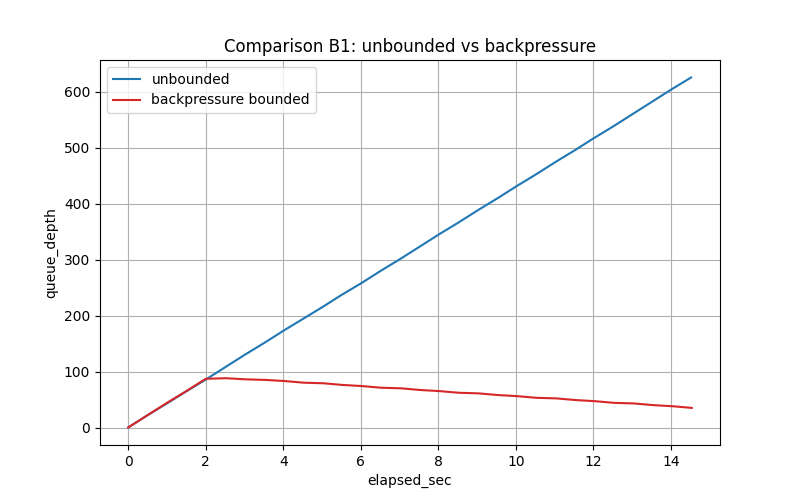

已将关键图片保存到 bigdata6_image


In [4]:
# 任务二：批量运行实验、保存 CSV 与绘图（包含背压对比）
import csv
import os
import queue
import threading
import time
from datetime import datetime
from m2_producer import EcommerceDataProducer
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPyImage

# 图片统一保存目录
img_dir = 'bigdata6_image'
os.makedirs(img_dir, exist_ok=True)

# 删除工作区根目录中旧的任务二图像，保留 CSV
for fn in list(os.listdir('.')):
    if fn.startswith('task2_') and fn.endswith('.png'):
        try:
            os.remove(fn)
        except Exception:
            pass
# 清理目标文件夹中的旧图
for fn in list(os.listdir(img_dir)):
    if fn.endswith('.png'):
        try:
            os.remove(os.path.join(img_dir, fn))
        except Exception:
            pass

# 复用 notebook 中的 Producer/Consumer/MetricsCollector 实现（若已定义则不重复定义）
try:
    Producer  # noqa: F401
    Consumer  # noqa: F401
    MetricsCollector  # noqa: F401
except NameError:
    import threading
    import time
    class Producer(threading.Thread):
        def __init__(self, q, rate, stop_event, backpressure_on=False, backpressure_state=None, producer_config=None, max_backoff=5.0):
            super().__init__(daemon=True)
            self.q = q
            self.rate = rate
            self.stop_event = stop_event
            self.backpressure_on = backpressure_on
            self.backpressure_state = backpressure_state
            self.max_backoff = max_backoff
            self.produced = 0
            self.dropped = 0
            self.data_producer = EcommerceDataProducer(**(producer_config or {}))
        def run(self):
            base_delay = 1.0 / self.rate if self.rate > 0 else 0
            current_delay = base_delay
            while not self.stop_event.is_set():
                event = self.data_producer.generate_event()
                try:
                    if self.backpressure_on:
                        self.q.put(event)
                    else:
                        try:
                            self.q.put_nowait(event)
                        except queue.Full:
                            self.dropped += 1
                            continue
                    self.produced += 1
                except queue.Full:
                    self.dropped += 1
                if self.backpressure_state is not None:
                    with self.backpressure_state['lock']:
                        active = bool(self.backpressure_state.get('active', False))
                    if active:
                        current_delay = min(max(base_delay, current_delay * 2), self.max_backoff)
                    else:
                        current_delay = max(base_delay, current_delay / 2) if base_delay > 0 else 0
                    if current_delay > 0:
                        time.sleep(current_delay)
                else:
                    if base_delay > 0:
                        time.sleep(base_delay)
    class Consumer(threading.Thread):
        def __init__(self, q, process_time, stop_event, consumed_counter):
            super().__init__(daemon=True)
            self.q = q
            self.process_time = process_time
            self.stop_event = stop_event
            self.consumed_counter = consumed_counter
        def run(self):
            while not self.stop_event.is_set():
                try:
                    _ = self.q.get(timeout=0.5)
                    time.sleep(self.process_time)
                    with self.consumed_counter['lock']:
                        self.consumed_counter['count'] += 1
                    try:
                        self.q.task_done()
                    except Exception:
                        pass
                except queue.Empty:
                    continue
    class MetricsCollector(threading.Thread):
        def __init__(self, q, max_capacity, producer_rate, consumer_time, n_consumers, backpressure_on, backpressure_state, stop_event, start_time, csv_path, high_threshold=0.85, low_threshold=0.30):
            super().__init__(daemon=True)
            self.q = q
            self.max_capacity = max_capacity
            self.producer_rate = producer_rate
            self.consumer_time = consumer_time
            self.n_consumers = n_consumers
            self.backpressure_on = backpressure_on
            self.backpressure_state = backpressure_state
            self.stop_event = stop_event
            self.start_time = start_time
            self.csv_path = csv_path
            self.high_threshold = high_threshold
            self.low_threshold = low_threshold
        def run(self):
            file_exists = os.path.exists(self.csv_path)
            file_empty = (not file_exists) or os.path.getsize(self.csv_path) == 0
            with open(self.csv_path, 'a', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                if file_empty:
                    writer.writerow(['timestamp','elapsed_sec','queue_depth','max_capacity','load_pct','producer_rate','consumer_time','n_consumers','backpressure_on','backpressure_active'])
                while not self.stop_event.is_set():
                    now = time.time()
                    elapsed = now - self.start_time
                    queue_depth = self.q.qsize()
                    load_pct = queue_depth / self.max_capacity if self.max_capacity > 0 else -1
                    back_active = False
                    if self.backpressure_on and self.backpressure_state is not None and self.max_capacity > 0:
                        with self.backpressure_state['lock']:
                            current_active = bool(self.backpressure_state.get('active', False))
                            if load_pct >= self.high_threshold and not current_active:
                                self.backpressure_state['active'] = True
                                back_active = True
                                print('⚠⚠ 触发背压：下游过载，强制削峰中...')
                            elif load_pct <= self.low_threshold and current_active:
                                self.backpressure_state['active'] = False
                                back_active = False
                                print('ℹ️ 背压缓解：逐渐恢复吞吐')
                            else:
                                back_active = bool(self.backpressure_state.get('active', False))
                    else:
                        back_active = False
                    writer.writerow([datetime.fromtimestamp(now).isoformat(), round(elapsed,2), queue_depth, self.max_capacity, round(load_pct,4) if load_pct!=-1 else -1, self.producer_rate, self.consumer_time, self.n_consumers, self.backpressure_on, back_active])
                    f.flush()
                    time.sleep(0.5)

# --------------- 实验配置与执行 ---------------
def run_experiment(name, duration_sec, producer_rate, consumer_time, n_consumers, max_capacity, backpressure_on, csv_path, producer_config=None, backpressure_params=None):
    if os.path.exists(csv_path):
        os.remove(csv_path)
    q = queue.Queue(max_capacity) if max_capacity>0 else queue.Queue()
    stop_event = threading.Event()
    consumed_counter = {'count':0,'lock':threading.Lock()}
    start_time = time.time()
    backpressure_state = None
    if backpressure_on and max_capacity>0:
        backpressure_state = {'active':False,'lock':threading.Lock()}
    producer = Producer(q, producer_rate, stop_event, backpressure_on=backpressure_on, backpressure_state=backpressure_state, producer_config=producer_config, max_backoff=(backpressure_params.get('max_backoff') if backpressure_params else 5.0))
    consumers = [Consumer(q, consumer_time, stop_event, consumed_counter) for _ in range(n_consumers)]
    metrics = MetricsCollector(q, max_capacity if max_capacity>0 else -1, producer_rate, consumer_time, n_consumers, backpressure_on, backpressure_state, stop_event, start_time, csv_path, high_threshold=(backpressure_params.get('high_threshold') if backpressure_params else 0.85), low_threshold=(backpressure_params.get('low_threshold') if backpressure_params else 0.30))
    producer.start()
    for c in consumers: c.start()
    metrics.start()
    time.sleep(duration_sec)
    stop_event.set()
    producer.join()
    for c in consumers: c.join()
    metrics.join()
    produced = producer.produced
    dropped = producer.dropped
    with consumed_counter['lock']: consumed = consumed_counter['count']
    final_depth = q.qsize()
    return {'name':name,'produced':produced,'consumed':consumed,'dropped':dropped,'final_depth':final_depth,'csv':csv_path}

# 实验表（无背压、有界为 0 表示无界）
experiments = {
    'A1': {'lambda':10,'t':0.2,'n':1},
    'A2': {'lambda':10,'t':0.05,'n':1},
    'B1': {'lambda':50,'t':0.2,'n':1},
    'B2': {'lambda':50,'t':0.2,'n':3},
    'C1': {'lambda':20,'t':0.05,'n':1},
    'C2': {'lambda':100,'t':0.05,'n':2},
}
results = {}
for name,p in experiments.items():
    csvname = f'task2_{name}_unbounded.csv'
    res = run_experiment(name, duration_sec=15, producer_rate=p['lambda'], consumer_time=p['t'], n_consumers=p['n'], max_capacity=0, backpressure_on=False, csv_path=csvname, producer_config={'num_users':1000,'num_items':500})
    results[name]=res

# 绘制并保存关键图片（只保存汇总图与两组对比图）
# 汇总图
plt.figure(figsize=(10,6))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown']
for (name,p),color in zip(experiments.items(),colors):
    csvname = f'task2_{name}_unbounded.csv'
    times=[]; depths=[]
    if os.path.exists(csvname):
        with open(csvname,'r',encoding='utf-8') as f:
            rdr = csv.DictReader(f)
            for r in rdr:
                times.append(float(r['elapsed_sec']))
                depths.append(float(r['queue_depth']))
    plt.plot(times,depths,label=f"{name} (λ={p['lambda']}, t={p['t']}, n={p['n']})",color=color)
plt.xlabel('elapsed_sec')
plt.ylabel('queue_depth')
plt.title('Task2: Unbounded queue experiments')
plt.legend()
plt.grid(True)
summary_path = os.path.join(img_dir, 'task2_unbounded_all.png')
plt.savefig(summary_path)
plt.close()
# 在输出中显示汇总图
display(IPyImage(filename=summary_path))

# 选择两组用于背压对比并绘制
bp_choices = ['A1','B1']
for name in bp_choices:
    p = experiments[name]
    csv_un = f'task2_{name}_unbounded.csv'
    csv_bp = f'task2_{name}_bp_bounded.csv'
    # 如果背压 CSV 尚未生成，则运行一次有背压实验
    if not os.path.exists(csv_bp):
        _ = run_experiment(name+'_bp', duration_sec=15, producer_rate=p['lambda'], consumer_time=p['t'], n_consumers=p['n'], max_capacity=100, backpressure_on=True, csv_path=csv_bp, producer_config={'num_users':1000,'num_items':500}, backpressure_params={'max_backoff':2.0,'high_threshold':0.85,'low_threshold':0.30})
    times_un=[]; depths_un=[]
    if os.path.exists(csv_un):
        with open(csv_un,'r',encoding='utf-8') as f:
            rdr = csv.DictReader(f)
            for r in rdr:
                times_un.append(float(r['elapsed_sec']))
                depths_un.append(float(r['queue_depth']))
    times_bp=[]; depths_bp=[]
    if os.path.exists(csv_bp):
        with open(csv_bp,'r',encoding='utf-8') as f:
            rdr = csv.DictReader(f)
            for r in rdr:
                times_bp.append(float(r['elapsed_sec']))
                depths_bp.append(float(r['queue_depth']))
    plt.figure(figsize=(8,5))
    plt.plot(times_un,depths_un,label='unbounded',color='tab:blue')
    plt.plot(times_bp,depths_bp,label='backpressure bounded',color='tab:red')
    plt.xlabel('elapsed_sec')
    plt.ylabel('queue_depth')
    plt.title(f'Comparison {name}: unbounded vs backpressure')
    plt.legend()
    plt.grid(True)
    cmp_path = os.path.join(img_dir, f'task2_{name}_comparison.png')
    plt.savefig(cmp_path)
    plt.close()
    display(IPyImage(filename=cmp_path))

# 保存斜率摘要（保留为文本文件）
import numpy as np
slope_results = {}
for name,p in experiments.items():
    csvname = f'task2_{name}_unbounded.csv'
    times=[]; depths=[]
    if os.path.exists(csvname):
        with open(csvname,'r',encoding='utf-8') as f:
            rdr = csv.DictReader(f)
            for r in rdr:
                times.append(float(r['elapsed_sec']))
                depths.append(float(r['queue_depth']))
    if len(times) >= 3:
        k = max(1, int(len(times)*0.4))
        xt = np.array(times[k:]); yt = np.array(depths[k:])
        A = np.vstack([xt, np.ones_like(xt)]).T
        m, c = np.linalg.lstsq(A, yt, rcond=None)[0]
        theoretical = p['lambda'] - (p['n'] / p['t'])
        slope_results[name] = {'measured_slope': float(m), 'theoretical_slope': float(theoretical)}
    else:
        slope_results[name] = {'measured_slope': None, 'theoretical_slope': float(p['lambda'] - (p['n']/p['t']))}
with open(os.path.join(img_dir, 'task2_slope_comparison.txt'), 'w', encoding='utf-8') as f:
    for name, res in slope_results.items():
        f.write(f"{name}: measured={res['measured_slope']}, theoretical={res['theoretical_slope']}\n")

print('已将关键图片保存到', img_dir)


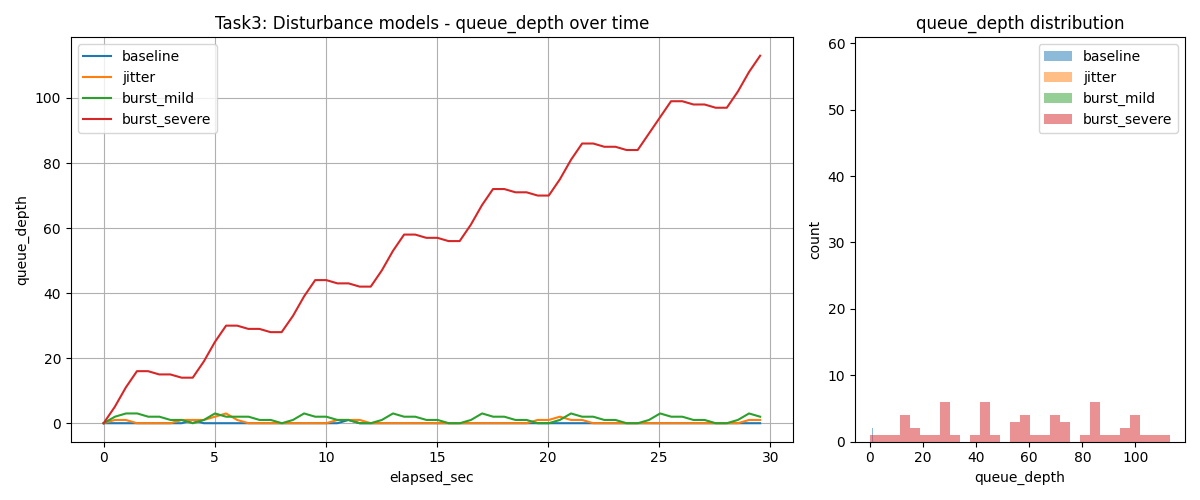

任务三运行完毕，关键图片与 backpressure_metrics.csv 已保存到 bigdata6_image


In [5]:
# 任务三：扰动模型对比（均匀抖动 vs 周期性突发）
import csv, os, queue, threading, time, random
from datetime import datetime
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPyImage

img_dir = 'bigdata6_image'
os.makedirs(img_dir, exist_ok=True)
# 清理工作区根目录中的旧 task3 图片，保留 CSV
for fn in list(os.listdir('.')):
    if fn.startswith('task3_') and fn.endswith('.png'):
        try:
            os.remove(fn)
        except Exception:
            pass
# 清理目标文件夹中的旧 task3 图片
for fn in list(os.listdir(img_dir)):
    if fn.startswith('task3_') and fn.endswith('.png'):
        try:
            os.remove(os.path.join(img_dir, fn))
        except Exception:
            pass

def run_experiment_pattern(name, duration_sec, base_rate, consumer_time, n_consumers, max_capacity, backpressure_on, csv_path, pattern='none', pattern_params=None):
    if os.path.exists(csv_path):
        os.remove(csv_path)
    q = queue.Queue(max_capacity) if max_capacity>0 else queue.Queue()
    stop_event = threading.Event()
    consumed = {'count':0, 'lock': threading.Lock()}
    start_time = time.time()
    pattern_params = pattern_params or {}

    class ProducerThread(threading.Thread):
        def __init__(self):
            super().__init__(daemon=True)
            self.produced = 0
            self.dropped = 0
        def run(self):
            while not stop_event.is_set():
                elapsed = time.time() - start_time
                if pattern == 'jitter':
                    jf = pattern_params.get('jitter_factor', 0.0)
                    delay = (1.0 / base_rate) * random.uniform(max(0,1-jf), 1+jf)
                elif pattern == 'burst':
                    interval = pattern_params.get('burst_interval', 4)
                    duration_b = pattern_params.get('burst_duration', 1)
                    mult = pattern_params.get('burst_multiplier', 2)
                    cycle_pos = elapsed % interval
                    in_burst = cycle_pos < duration_b
                    rate = base_rate * mult if in_burst else base_rate
                    delay = 1.0 / rate
                else:
                    delay = 1.0 / base_rate
                evt = {'ts': time.time()}
                try:
                    if backpressure_on and max_capacity>0:
                        q.put(evt)
                    else:
                        try:
                            q.put_nowait(evt)
                        except queue.Full:
                            self.dropped += 1
                    self.produced += 1
                except queue.Full:
                    self.dropped += 1
                time.sleep(delay)

    # 尝试复用 notebook 已有的 Consumer 类，否则定义一个轻量版
    try:
        Consumer  # noqa: F401
    except NameError:
        class Consumer(threading.Thread):
            def __init__(self, q, process_time, stop_event, consumed_counter):
                super().__init__(daemon=True)
                self.q = q
                self.process_time = process_time
                self.stop_event = stop_event
                self.consumed_counter = consumed_counter
            def run(self):
                while not self.stop_event.is_set():
                    try:
                        _ = self.q.get(timeout=0.5)
                        time.sleep(self.process_time)
                        with self.consumed_counter['lock']:
                            self.consumed_counter['count'] += 1
                        try:
                            self.q.task_done()
                        except Exception:
                            pass
                    except queue.Empty:
                        continue

    producer = ProducerThread()
    consumers = [Consumer(q, consumer_time, stop_event, consumed) for _ in range(n_consumers)]

    def monitor():
        with open(csv_path, 'a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['timestamp','elapsed_sec','queue_depth','producer_rate','consumer_time','n_consumers','backpressure_on'])
            while not stop_event.is_set():
                now = time.time()
                elapsed = now - start_time
                qdepth = q.qsize()
                writer.writerow([datetime.fromtimestamp(now).isoformat(), round(elapsed,2), qdepth, base_rate, consumer_time, n_consumers, backpressure_on])
                f.flush()
                time.sleep(0.5)

    monitor_thread = threading.Thread(target=monitor, daemon=True)

    producer.start()
    for c in consumers: c.start()
    monitor_thread.start()

    time.sleep(duration_sec)
    stop_event.set()
    producer.join()
    for c in consumers: c.join()
    monitor_thread.join()

    return {'produced': producer.produced, 'dropped': producer.dropped, 'consumed': consumed['count'], 'final_depth': q.qsize(), 'csv': csv_path}

# ------------- 实验配置（基线可被视为稳定：lambda=4, t=0.2, n=1 => mu=5） -------------
base_rate = 4
consumer_t = 0.2
n_consumers = 1
duration = 30  # 秒，包含多个突发周期以便观察
experiments = [
    ('baseline', 'none', {}),
    ('jitter', 'jitter', {'jitter_factor': 0.9}),
    ('burst_mild', 'burst', {'burst_multiplier': 2, 'burst_interval': 4, 'burst_duration': 1}),
    ('burst_severe', 'burst', {'burst_multiplier': 4, 'burst_interval': 4, 'burst_duration': 1.5}),
]
results3 = {}
for name, pattern, params in experiments:
    csvname = f'task3_{name}.csv'
    res = run_experiment_pattern(name, duration, base_rate, consumer_t, n_consumers, max_capacity=0, backpressure_on=False, csv_path=csvname, pattern=pattern, pattern_params=params)
    results3[name] = res

# 绘图：左子图时间序列，右子图为队列深度分布直方图
plt.figure(figsize=(12,5))
ax1 = plt.subplot2grid((1,3),(0,0),colspan=2)
ax2 = plt.subplot2grid((1,3),(0,2))
colors = {'baseline':'tab:blue','jitter':'tab:orange','burst_mild':'tab:green','burst_severe':'tab:red'}
all_depths = {}
for name, _, _ in experiments:
    csvname = f'task3_{name}.csv'
    times=[]; depths=[]
    if os.path.exists(csvname):
        with open(csvname,'r',encoding='utf-8') as f:
            rdr = csv.DictReader(f)
            for r in rdr:
                times.append(float(r['elapsed_sec']))
                depths.append(float(r['queue_depth']))
    all_depths[name] = depths
    ax1.plot(times, depths, label=name, color=colors.get(name,'k'))
ax1.set_xlabel('elapsed_sec')
ax1.set_ylabel('queue_depth')
ax1.set_title('Task3: Disturbance models - queue_depth over time')
ax1.legend()
ax1.grid(True)
# 右侧直方图（归一化显示多个分布）
for name, depths in all_depths.items():
    if len(depths)>0:
        ax2.hist(depths, bins=30, alpha=0.5, label=name, color=colors.get(name,'k'))
ax2.set_title('queue_depth distribution')
ax2.set_xlabel('queue_depth')
ax2.set_ylabel('count')
ax2.legend()
plt.tight_layout()
cmp_path = os.path.join(img_dir, 'task3_comparison.png')
plt.savefig(cmp_path)
plt.close()
display(IPyImage(filename=cmp_path))

# 保存包含背压 + 激烈突发 的水位数据作为 backpressure_metrics.csv（有界队列 maxsize=100）
bp_csv = os.path.join(img_dir, 'backpressure_metrics.csv')
_ = run_experiment_pattern('burst_severe_bp', duration, base_rate, consumer_t, n_consumers, max_capacity=100, backpressure_on=True, csv_path=bp_csv, pattern='burst', pattern_params={'burst_multiplier':4,'burst_interval':4,'burst_duration':1.5})
print('任务三运行完毕，关键图片与 backpressure_metrics.csv 已保存到', img_dir)

In [3]:
# 任务四（独立单元）：CSV 流式 Producer + Consumer 中应用 sklearn Pipeline（修正版）
import csv, os, json, queue, threading, time
from datetime import datetime
import numpy as np

# 不要修改下方 DATA_PATH（用户要求）
DATA_PATH = r'C:\Users\caoruijie\Desktop\UserBehavior.csv'
N_FIT = 1000
NUMERIC_COLS = ['category_id', 'timestamp']  # 优先使用这两列
FITTED_PIPE_PATH = 'preprocess_pipe.joblib'
PIPE_META_PATH = 'preprocess_pipe_meta.json'
AUTO_DETECT_THRESHOLD = 0.6

# 无表头时使用的标准列名（UserBehavior 常见格式）
EXPECTED_COLS = ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']

# 依赖导入
SKLEARN_READY = True
try:
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    import joblib
except Exception as e:
    SKLEARN_READY = False
    print('请先安装 scikit-learn 与 joblib：', e)


def _safe_float(v):
    try:
        if v is None or v == '':
            return np.nan
        return float(v)
    except Exception:
        return np.nan


def _looks_like_header(first_row):
    """判断首行是否像表头。"""
    if not first_row:
        return False
    row_l = [str(x).strip().lower() for x in first_row]
    expected_l = [x.lower() for x in EXPECTED_COLS]
    hit = sum(1 for x in row_l if x in expected_l)
    # 命中 >=2 个标准字段，基本可判定为表头
    if hit >= 2:
        return True
    # 如果几乎全是数字/枚举值，通常不是表头
    numeric_cnt = 0
    for x in row_l:
        try:
            float(x)
            numeric_cnt += 1
        except Exception:
            pass
    if numeric_cnt >= len(row_l) - 1:
        return False
    return False


def _make_fieldnames(col_count):
    if col_count == 5:
        return EXPECTED_COLS[:]  # 常见 UserBehavior 五列
    return [f'col_{i}' for i in range(col_count)]


def load_sample_rows(path, n_rows):
    """返回 (header, sample_rows, has_header)。自动处理有表头/无表头。"""
    if not os.path.exists(path):
        return [], [], False

    with open(path, 'r', encoding='utf-8', errors='ignore', newline='') as f:
        reader = csv.reader(f)
        first_row = next(reader, None)

    if first_row is None:
        return [], [], False

    has_header = _looks_like_header(first_row)

    sample = []
    with open(path, 'r', encoding='utf-8', errors='ignore', newline='') as f:
        if has_header:
            rdr = csv.DictReader(f)
            header = rdr.fieldnames or []
        else:
            fieldnames = _make_fieldnames(len(first_row))
            rdr = csv.DictReader(f, fieldnames=fieldnames)
            header = fieldnames
        for i, r in enumerate(rdr):
            sample.append(r)
            if i + 1 >= n_rows:
                break
    return header, sample, has_header


def detect_numeric_cols(header, sample_rows, preferred_cols, threshold=0.6):
    # 先尝试优先列
    selected = [c for c in preferred_cols if c in header]
    if selected:
        return selected

    # 自动检测“可转 float 占比”高的列
    scores = {}
    for col in header:
        ok, tot = 0, 0
        for r in sample_rows:
            v = r.get(col, '')
            if v is None or v == '':
                continue
            tot += 1
            try:
                float(v)
                ok += 1
            except Exception:
                pass
        scores[col] = (ok / tot) if tot > 0 else 0.0

    selected = [c for c, s in scores.items() if s >= threshold]
    if len(selected) < 2:
        # 保底取得分最高的前2-4列
        selected = [c for c, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:4]]
    return selected


def prepare_pipeline():
    """
    加载已保存 pipeline 或重新 fit，返回 (pipeline, numeric_cols)
    """
    if not os.path.exists(DATA_PATH):
        print('数据文件不存在：', DATA_PATH)
        return None, []

    header, sample, has_header = load_sample_rows(DATA_PATH, N_FIT)
    if not header or not sample:
        print('CSV 为空或不可解析')
        return None, []

    print('CSV 检测：', '有表头' if has_header else '无表头（已自动映射标准列名）')
    print('解析列名：', header)

    numeric_cols = detect_numeric_cols(header, sample, NUMERIC_COLS, AUTO_DETECT_THRESHOLD)
    if not numeric_cols:
        print('未检测到可用数值列')
        return None, []

    if not SKLEARN_READY:
        print('sklearn 不可用，将仅消费不 transform')
        return None, numeric_cols

    # 尝试读取缓存并校验列一致
    if os.path.exists(FITTED_PIPE_PATH) and os.path.exists(PIPE_META_PATH):
        try:
            meta = json.load(open(PIPE_META_PATH, 'r', encoding='utf-8'))
            if meta.get('numeric_cols') == numeric_cols:
                pipe = joblib.load(FITTED_PIPE_PATH)
                print('Loaded pipeline from', FITTED_PIPE_PATH)
                return pipe, numeric_cols
            else:
                print('缓存列与当前列不一致，重新 fit')
        except Exception as e:
            print('加载缓存失败，重新 fit：', e)

    X = []
    for r in sample:
        X.append([_safe_float(r.get(c, '')) for c in numeric_cols])
    X = np.array(X, dtype=float)

    if X.size == 0 or X.shape[1] == 0:
        print('训练矩阵无有效特征，跳过 fit')
        return None, numeric_cols

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    pipe.fit(X)

    try:
        joblib.dump(pipe, FITTED_PIPE_PATH)
        with open(PIPE_META_PATH, 'w', encoding='utf-8') as mf:
            json.dump({'numeric_cols': numeric_cols, 'n_fit': len(sample)}, mf, ensure_ascii=False, indent=2)
        print('保存 fitted pipeline ->', FITTED_PIPE_PATH)
    except Exception as e:
        print('保存 pipeline/meta 失败：', e)

    return pipe, numeric_cols


class CSVProducer(threading.Thread):
    def __init__(self, q, rate, path, stop_event):
        super().__init__(daemon=True)
        self.q = q
        self.rate = max(0.0001, float(rate))
        self.path = path
        self.stop_event = stop_event
        self.produced = 0
        self.blocked = 0

    def run(self):
        if not os.path.exists(self.path):
            print('CSV 不存在：', self.path)
            return

        # 统一用 load_sample_rows 的同逻辑判定是否有表头
        header, _, has_header = load_sample_rows(self.path, 1)

        with open(self.path, 'r', encoding='utf-8', errors='ignore', newline='') as f:
            if has_header:
                rdr = csv.DictReader(f)
            else:
                rdr = csv.DictReader(f, fieldnames=header)

            for row in rdr:
                if self.stop_event.is_set():
                    break
                while not self.stop_event.is_set():
                    try:
                        self.q.put(row, timeout=0.5)  # 防止满队列永久阻塞
                        self.produced += 1
                        break
                    except queue.Full:
                        self.blocked += 1
                time.sleep(1.0 / self.rate)


class TransformConsumer(threading.Thread):
    def __init__(self, q, pipe, cols, stop_event, print_every=10):
        super().__init__(daemon=True)
        self.q = q
        self.pipe = pipe
        self.cols = cols or []
        self.stop_event = stop_event
        self.print_every = max(1, int(print_every))
        self.cnt = 0
        self.transform_ok = 0
        self.transform_fail = 0
        self.z_records = []

    def run(self):
        if not self.cols:
            print('注意：无数值列，Consumer 仅消费')
        if self.pipe is None and self.cols:
            print('注意：无 pipeline，Consumer 不做 transform')

        # stop 后继续消费到队列空，避免卡死
        while not (self.stop_event.is_set() and self.q.empty()):
            try:
                row = self.q.get(timeout=0.5)
            except queue.Empty:
                continue

            try:
                vals = [_safe_float(row.get(c, '')) for c in self.cols]
                xt = None
                if self.pipe is not None and self.cols:
                    try:
                        xt = self.pipe.transform(np.array([vals], dtype=float))[0].tolist()
                        self.transform_ok += 1
                        self.z_records.append(xt)
                    except Exception as e:
                        self.transform_fail += 1
                        print('transform 出错：', e)

                self.cnt += 1
                if self.cnt % self.print_every == 0:
                    print(f'[{datetime.now().isoformat()}] 原始: {vals} -> 标准化: {xt}')
            finally:
                self.q.task_done()


# 准备 pipeline
preprocess_pipe, numeric_cols_used = prepare_pipeline()


def run_task4_demo(duration_sec=20, producer_rate=10, max_capacity=1000, print_every=10):
    q = queue.Queue(max_capacity) if max_capacity > 0 else queue.Queue()
    stop_event = threading.Event()

    p = CSVProducer(q, producer_rate, DATA_PATH, stop_event)
    c = TransformConsumer(q, preprocess_pipe, numeric_cols_used, stop_event, print_every=print_every)

    start = time.time()
    p.start()
    c.start()

    try:
        time.sleep(duration_sec)
    finally:
        stop_event.set()

    p.join(timeout=10)
    c.join(timeout=20)

    summary = {
        'duration_sec': round(time.time() - start, 2),
        'produced': p.produced,
        'producer_blocked_count': p.blocked,
        'consumed': c.cnt,
        'transform_ok': c.transform_ok,
        'transform_fail': c.transform_fail,
        'final_queue_depth': q.qsize(),
        'numeric_cols_used': numeric_cols_used
    }

    # 输出在线 z-score 统计（用于漂移判断）
    if c.z_records:
        arr = np.array(c.z_records, dtype=float)
        z_mean = np.nanmean(arr, axis=0).tolist()
        z_std = np.nanstd(arr, axis=0).tolist()
        summary['online_z_mean'] = dict(zip(numeric_cols_used, [round(x, 4) for x in z_mean]))
        summary['online_z_std'] = dict(zip(numeric_cols_used, [round(x, 4) for x in z_std]))

    print('任务四演示结束：', summary)
    return summary


print('任务四单元就绪。运行示例：')
print("run_task4_demo(duration_sec=30, producer_rate=20, max_capacity=100, print_every=10)")
run_task4_demo(duration_sec=30, producer_rate=20, max_capacity=100, print_every=10)


CSV 检测： 无表头（已自动映射标准列名）
解析列名： ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']
缓存列与当前列不一致，重新 fit
保存 fitted pipeline -> preprocess_pipe.joblib
任务四单元就绪。运行示例：
run_task4_demo(duration_sec=30, producer_rate=20, max_capacity=100, print_every=10)
[2026-04-18T17:40:38.167560] 原始: [2920476.0, 1511733732.0] -> 标准化: [0.13100396737855968, -0.7211653252516536]
[2026-04-18T17:40:38.671307] 原始: [4145813.0, 1511870864.0] -> 标准化: [0.9523587924896724, -0.12169389033436373]
[2026-04-18T17:40:39.176093] 原始: [2520771.0, 1511969365.0] -> 标准化: [-0.13692202389652408, 0.30890243882869056]
[2026-04-18T17:40:39.680104] 原始: [2355072.0, 1512064350.0] -> 标准化: [-0.24799160978684345, 0.7241286022742669]
[2026-04-18T17:40:40.183593] 原始: [3002561.0, 1512251522.0] -> 标准化: [0.18602630883992555, 1.5423494946723868]
[2026-04-18T17:40:40.688355] 原始: [4869428.0, 1511550908.0] -> 标准化: [1.437404679272474, -1.5203789706248603]
[2026-04-18T17:40:41.194376] 原始: [4869428.0, 1511565222.0] -> 标准化: [1.43740467927247

{'duration_sec': 30.5,
 'produced': 596,
 'producer_blocked_count': 0,
 'consumed': 596,
 'transform_ok': 596,
 'transform_fail': 0,
 'final_queue_depth': 0,
 'numeric_cols_used': ['category_id', 'timestamp'],
 'online_z_mean': {'category_id': -0.0676, 'timestamp': -0.066},
 'online_z_std': {'category_id': 0.9862, 'timestamp': 0.974}}